In [1]:
# Cell 1: Install required packages
import subprocess

packages = [
    "transformers>=4.45.0",
    "peft>=0.13.0",
    "bitsandbytes>=0.43.0",
    "accelerate>=0.34.0",
    "datasets",
    "qwen-vl-utils",
    "gradio",
    "Pillow",
    "tqdm",
    "matplotlib"
]

for pkg in packages:
    subprocess.run(["pip", "install", "-q", pkg], check=False)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 57.7 MB/s eta 0:00:00


In [2]:
# Cell 2: Core imports
import os
import json
import random
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from pathlib import Path
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoProcessor,
    Qwen2VLForConditionalGeneration,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}:", torch.cuda.get_device_name(i))

Torch version: 2.10.0+cu128
CUDA available: True
GPU count: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [3]:
# Cell 3: Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Part 1: Dataset Exploration

In [4]:
# Cell 4: Locate the Nougat dataset
# Kaggle mounts datasets under /kaggle/input/
dataset_root = Path("/kaggle/input/datasets/zphilip/nougat-training-dataset-example")

# List top-level contents so we understand the folder structure
print("Top-level entries:")
for entry in sorted(dataset_root.iterdir()):
    print(" ", entry)

Top-level entries:
  /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508
  /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508.jsonl


In [5]:
# Cell 5: Gather all valid image-markdown pairs from the dataset

def collect_pairs(root):
    pairs = []
    image_paths = sorted(root.rglob("*.png"))
    for img_path in image_paths:
        md_path = img_path.with_suffix(".mmd")
        if not md_path.exists():
            md_path = img_path.with_suffix(".txt")
        if not md_path.exists():
            continue
        try:
            with Image.open(img_path) as test_img:
                test_img.load()   # verify() ki jagah load() use karo
            pairs.append({"image": img_path, "markdown": md_path})
        except Exception:
            pass
    return pairs

all_pairs = collect_pairs(dataset_root)
print(f"Total valid image-markdown pairs found: {len(all_pairs)}")

Total valid image-markdown pairs found: 14207


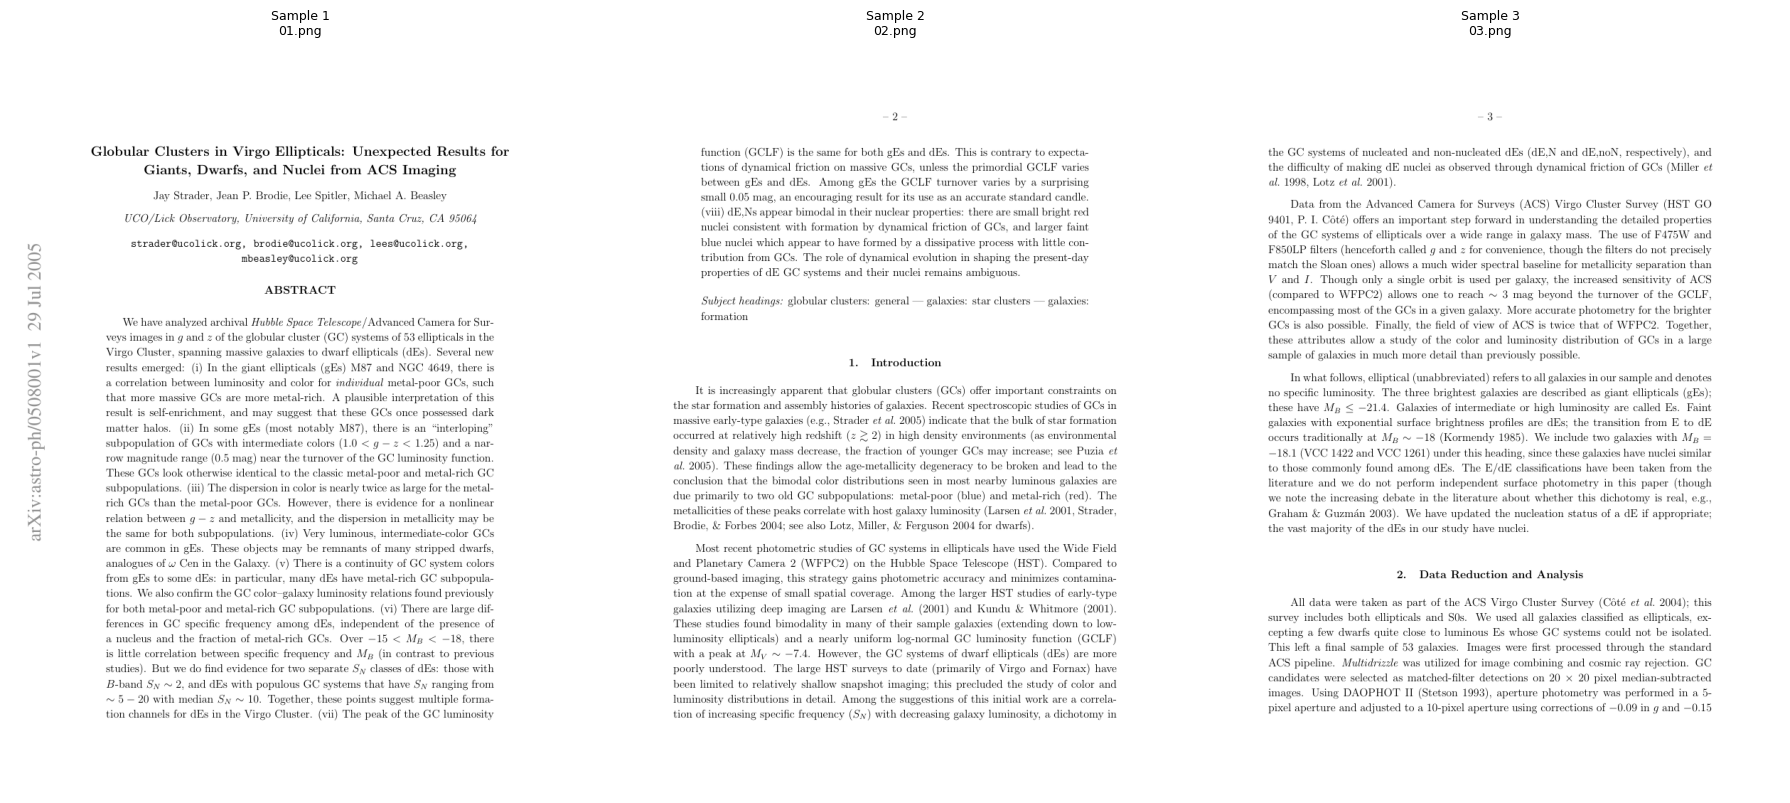


Corresponding Markdown (first 300 chars each):

--- Sample 1 ---
# Globular Clusters in Virgo Ellipticals: Unexpected Results for Giants, Dwarfs, and Nuclei from ACS Imaging

Jay Strader, Jean P. Brodie, Lee Spitler, Michael A. Beasley

UCO/Lick Observatory, University of California, Santa Cruz, CA 95064 strader@ucolick.org, brodie@ucolick.org, lees@ucolick.org, 

--- Sample 2 ---
function (GCLF) is the same for both gEs and dEs. This is contrary to expectations of dynamical friction on massive GCs, unless the primordial GCLF varies between gEs and dEs. Among gEs the GCLF turnover varies by a surprising small 0.05 mag, an encouraging result for its use as an accurate standard

--- Sample 3 ---
the GC systems of nucleated and non-nucleated dEs (dE,N and dE,noN, respectively), and the difficulty of making dE nuclei as observed through dynamical friction of GCs (Miller _et al._ 1998, Lotz _et al._ 2001).

Data from the Advanced Camera for Surveys (ACS) Virgo Cluster Survey (HST GO 9401, 

In [6]:
# Cell 6: Visual inspection of a few samples
sample_count = min(3, len(all_pairs))

fig, axes = plt.subplots(1, sample_count, figsize=(6 * sample_count, 8))
if sample_count == 1:
    axes = [axes]

for idx, pair in enumerate(all_pairs[:sample_count]):
    img = Image.open(pair["image"]).convert("RGB")
    axes[idx].imshow(img)
    axes[idx].set_title(f"Sample {idx + 1}\n{pair['image'].name}", fontsize=9)
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig("sample_images.png", dpi=100)
plt.show()

print("\nCorresponding Markdown (first 300 chars each):")
for idx, pair in enumerate(all_pairs[:sample_count]):
    md_text = pair["markdown"].read_text(encoding="utf-8", errors="ignore")
    print(f"\n--- Sample {idx + 1} ---")
    print(md_text[:300])

In [7]:
# Cell 7: Basic statistics about the dataset
md_lengths = []
img_sizes = []

for pair in all_pairs:
    try:
        md_text = pair["markdown"].read_text(encoding="utf-8", errors="ignore")
        md_lengths.append(len(md_text))
        with Image.open(pair["image"]) as img:
            img_sizes.append(img.size)
    except Exception:
        pass

print(f"Valid samples after filtering: {len(md_lengths)}")
print("Markdown length stats:")
print(f"  Min : {min(md_lengths)}")
print(f"  Max : {max(md_lengths)}")
print(f"  Mean: {int(sum(md_lengths) / len(md_lengths))}")

widths  = [s[0] for s in img_sizes]
heights = [s[1] for s in img_sizes]
print("\nImage size stats (W x H):")
print(f"  Width  range: {min(widths)} - {max(widths)}")
print(f"  Height range: {min(heights)} - {max(heights)}")

Valid samples after filtering: 14207
Markdown length stats:
  Min : 1
  Max : 59339
  Mean: 3167

Image size stats (W x H):
  Width  range: 794 - 1056
  Height range: 816 - 1123


## Part 2: Data Preparation — ChatML Format

In [9]:
# Cell 8: Convert pairs to ChatML-style records
# Each record holds the raw image path and the target markdown text.
# The instruction prompt is kept fixed across all samples.

INSTRUCTION = (
    "Convert the document image into well-structured Markdown. "
    "Preserve all headings, equations, tables, lists, and captions faithfully."
)

def build_chatml_record(pair):
    md_text = pair["markdown"].read_text(encoding="utf-8", errors="ignore").strip()
    return {
        "image_path": str(pair["image"]),
        "instruction": INSTRUCTION,
        "target": md_text
    }

chatml_data = [build_chatml_record(p) for p in all_pairs]
print(f"ChatML records prepared: {len(chatml_data)}")
print("\nSingle record preview (target truncated):")
rec = chatml_data[0].copy()
rec["target"] = rec["target"][:200] + "..."
print(json.dumps(rec, indent=2))

ChatML records prepared: 14207

Single record preview (target truncated):
{
  "image_path": "/kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/astro-ph0508001/01.png",
  "instruction": "Convert the document image into well-structured Markdown. Preserve all headings, equations, tables, lists, and captions faithfully.",
  "target": "# Globular Clusters in Virgo Ellipticals: Unexpected Results for Giants, Dwarfs, and Nuclei from ACS Imaging\n\nJay Strader, Jean P. Brodie, Lee Spitler, Michael A. Beasley\n\nUCO/Lick Observatory, Univer..."
}


## Part 3: Dataset Splitting

In [10]:
# Cell 9: Subset + Train / Validation split (80 / 20)
MAX_SAMPLES = 2500

random.shuffle(chatml_data)
chatml_data = chatml_data[:MAX_SAMPLES]

split_idx  = int(len(chatml_data) * 0.8)
train_data = chatml_data[:split_idx]
val_data   = chatml_data[split_idx:]

print(f"Using {len(chatml_data)} samples out of the full dataset.")
print(f"Training samples  : {len(train_data)}")
print(f"Validation samples: {len(val_data)}")

Using 2500 samples out of the full dataset.
Training samples  : 2000
Validation samples: 500


In [12]:
# Cell 10: PyTorch Dataset class
TARGET_SIZE = 512   # resize shorter edge to this before feeding the model

class NougatDataset(Dataset):
    def __init__(self, records, processor, max_new_tokens=512):
        self.records = records
        self.processor = processor
        self.max_new_tokens = max_new_tokens

    def __len__(self):
        return len(self.records)

    def _resize_image(self, path):
        img = Image.open(path).convert("RGB")
        w, h = img.size
        scale = TARGET_SIZE / min(w, h)
        new_w = int(w * scale)
        new_h = int(h * scale)
        return img.resize((new_w, new_h), Image.LANCZOS)

    def __getitem__(self, idx):
        rec = self.records[idx]
        image = self._resize_image(rec["image_path"])

        # Build the conversation in the format Qwen2-VL expects
        conversation = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text",  "text": rec["instruction"]}
                ]
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": rec["target"]}]
            }
        ]
        return {"conversation": conversation, "image": image}

## Part 4: QLoRA Fine-Tuning

In [13]:
# Cell 11: Load processor and quantized model
MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)

base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

base_model.config.use_cache = False
print("Model loaded successfully.")

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

Model loaded successfully.


In [14]:
# Cell 12: Attach LoRA adapters
lora_cfg = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, lora_cfg)
model.print_trainable_parameters()

trainable params: 4,358,144 || all params: 2,213,343,744 || trainable%: 0.1969


In [15]:
# Cell 13: Collate function — produces batched tensors from conversations
def collate_fn(batch):
    conversations = [item["conversation"] for item in batch]
    images_list   = [item["image"]        for item in batch]

    # Apply chat template to get text tokens
    texts = [
        processor.apply_chat_template(conv, tokenize=False, add_generation_prompt=False)
        for conv in conversations
    ]

    inputs = processor(
        text=texts,
        images=images_list,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=1024
    )

    # Labels: mask padding tokens with -100 so they don't contribute to loss
    labels = inputs["input_ids"].clone()
    pad_id = processor.tokenizer.pad_token_id
    if pad_id is not None:
        labels[labels == pad_id] = -100

    inputs["labels"] = labels
    return inputs

In [16]:
# Cell 14: Build DataLoaders
BATCH_SIZE = 1

train_dataset = NougatDataset(train_data, processor)
val_dataset   = NougatDataset(val_data,   processor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")

Train batches: 2000
Val   batches: 500


In [17]:
# Cell 15: Training configuration
EPOCHS              = 3
LEARNING_RATE       = 1.5e-4
GRAD_ACCUM_STEPS    = 4
SAVE_DIR            = "/kaggle/working/checkpoints"

os.makedirs(SAVE_DIR, exist_ok=True)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=0.01
)

total_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * EPOCHS
scheduler   = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

print(f"Total optimiser steps: {total_steps}")

Total optimiser steps: 1500


In [18]:
# Cell 16: Validation loss helper
def compute_val_loss(model, loader, device, max_batches=20):
    model.eval()
    total_loss = 0.0
    counted    = 0
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= max_batches:
                break
            batch = {k: v.to(device) for k, v in batch.items()}
            out   = model(**batch)
            total_loss += out.loss.item()
            counted    += 1
    model.train()
    return total_loss / max(counted, 1)

In [19]:
# Cell 17: Main training loop
device = next(model.parameters()).device

train_losses = []
val_losses   = []
global_step  = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}")

    for step, batch in enumerate(pbar):
        batch = {k: v.to(device) for k, v in batch.items()}

        out  = model(**batch)
        loss = out.loss / GRAD_ACCUM_STEPS
        loss.backward()

        running_loss += out.loss.item()

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

        avg = running_loss / (step + 1)
        pbar.set_postfix({"loss": f"{avg:.4f}"})

    epoch_train_loss = running_loss / len(train_loader)
    epoch_val_loss   = compute_val_loss(model, val_loader, device)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch + 1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    ckpt_path = os.path.join(SAVE_DIR, f"epoch_{epoch + 1}")
    model.save_pretrained(ckpt_path)
    processor.save_pretrained(ckpt_path)
    print(f"Checkpoint saved to {ckpt_path}")

print("Training complete.")


Epoch 1/3: 100%|██████████| 2000/2000 [1:03:43<00:00,  1.91s/it, loss=3.7769]


Epoch 1 | Train Loss: 3.7769 | Val Loss: 3.6450
Checkpoint saved to /kaggle/working/checkpoints/epoch_1



Epoch 2/3: 100%|██████████| 2000/2000 [1:03:38<00:00,  1.91s/it, loss=3.5831]


Epoch 2 | Train Loss: 3.5831 | Val Loss: 3.6353
Checkpoint saved to /kaggle/working/checkpoints/epoch_2



Epoch 3/3: 100%|██████████| 2000/2000 [1:03:33<00:00,  1.91s/it, loss=3.5736]


Epoch 3 | Train Loss: 3.5736 | Val Loss: 3.6356
Checkpoint saved to /kaggle/working/checkpoints/epoch_3
Training complete.


## Fine-Tuning Results

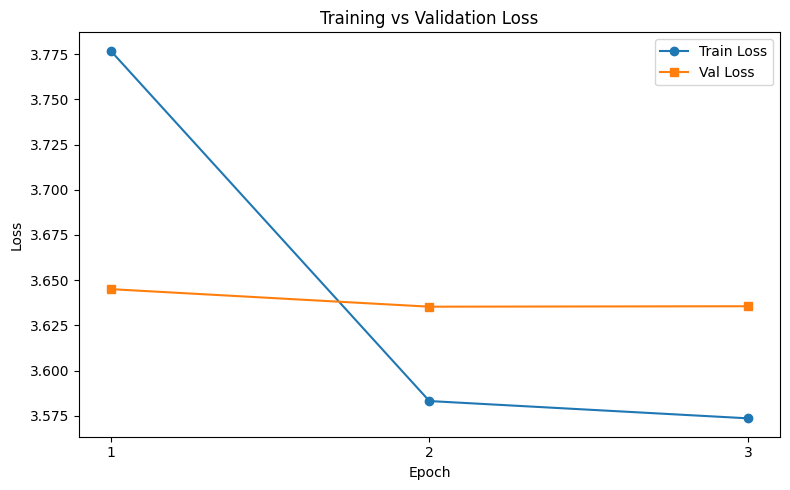

Loss values:
  Epoch 1: Train=3.7769  Val=3.6450
  Epoch 2: Train=3.5831  Val=3.6353
  Epoch 3: Train=3.5736  Val=3.6356


In [20]:
# Cell 18: Plot training and validation loss
epochs_range = list(range(1, EPOCHS + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, marker="o", label="Train Loss")
plt.plot(epochs_range, val_losses,   marker="s", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.xticks(epochs_range)
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/loss_curve.png", dpi=120)
plt.show()

print("Loss values:")
for i, (tl, vl) in enumerate(zip(train_losses, val_losses), 1):
    print(f"  Epoch {i}: Train={tl:.4f}  Val={vl:.4f}")

## Part 5: Markdown Generation on Validation Set

In [21]:
# Cell 19: Load the best checkpoint for inference
best_ckpt = os.path.join(SAVE_DIR, f"epoch_{EPOCHS}")

inf_processor = AutoProcessor.from_pretrained(best_ckpt, trust_remote_code=True)

inf_base = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

inf_model = PeftModel.from_pretrained(inf_base, best_ckpt)
inf_model.eval()
print("Fine-tuned model ready for inference.")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Fine-tuned model ready for inference.


In [22]:
# Cell 20: Single-image generation helper
def generate_markdown(model, processor, image_path, max_new_tokens=512):
    img = Image.open(image_path).convert("RGB")
    w, h = img.size
    scale = TARGET_SIZE / min(w, h)
    img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)

    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": img},
                {"type": "text",  "text": INSTRUCTION}
            ]
        }
    ]

    text = processor.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[img], return_tensors="pt").to(next(model.parameters()).device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None
        )

    generated = output_ids[0][inputs["input_ids"].shape[1]:]
    return processor.decode(generated, skip_special_tokens=True)

In [23]:
# Cell 21: Run inference on 3 validation samples and compare with ground truth
val_samples = val_data[:3]
val_results = []

for i, rec in enumerate(val_samples):
    generated = generate_markdown(inf_model, inf_processor, rec["image_path"])
    ground_truth = rec["target"]
    val_results.append({
        "image_path":   rec["image_path"],
        "ground_truth": ground_truth,
        "generated":    generated
    })
    print(f"\n{'='*60}")
    print(f"Validation Sample {i + 1}: {Path(rec['image_path']).name}")
    print(f"{'='*60}")
    print("GROUND TRUTH (first 300 chars):")
    print(ground_truth[:300])
    print("\nGENERATED (first 300 chars):")
    print(generated[:300])

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Validation Sample 1: 11.png
GROUND TRUTH (first 300 chars):
Pentium IV Xeon 2.0Ghz with two processors, 4Gb of RAM memory, running Fedora Core 2.0, and averaging several runs after eliminating the best and worst values. Ciao version 1.11#326 and CiaoPP 1.0#2292 were used. Columns labeled **precision** show the number of sharing groups in the information infe

GENERATED (first 300 chars):
Pentium IV Xeon 2.0Ghz with two processors, 4Gb of RAM memory, running Fedora Core 2.0, and averaging several runs after eliminating the best and worst values. Class version 1.11-326 and GSoPP 1.0-2292 were used. Columns labeled _precision_ show the number of sharing groups in the information inferr

Validation Sample 2: 01.png
GROUND TRUTH (first 300 chars):
# Fermionic Zero Modes in Self-dual Vortex Background

+
Footnote †: thanks: Corresponding author

Yong-Qiang Wang

wyq02@st.lzu.edu.cn Institute of Theoretical Physics, Lanzhou University, Lanzhou 730000, China

Tie-Yan Si

city02@st.lzu.edu.cn 

## Part 6: Testing — Training Images & Unseen Documents

In [25]:
# Cell 22: Generate markdown for 3 training images
train_test_samples = train_data[:3]
train_test_results = []

for i, rec in enumerate(train_test_samples):
    generated = generate_markdown(inf_model, inf_processor, rec["image_path"])
    train_test_results.append({
        "image_path": rec["image_path"],
        "generated":  generated
    })
    print(f"\nTraining Image {i + 1}: {Path(rec['image_path']).name}")
    print("Generated (first 300 chars):")
    print(generated[:300])


Training Image 1: 06.png
Generated (first 300 chars):
Without loss of generality we may consider a regular polygon in the plane spanned by the first two coordinate axes and to parametrize its vertices in the following way,

\[\tilde{y}_{2m}=\frac{L}{N}\left(\pm\sum_{n=0}^{m}\cos\frac{\pi}{N}(2n+1),\sum_{n=0}^{m}\sin \frac{\pi}{N}(2n+1)\right),\]

so th

Training Image 2: 23.png
Generated (first 300 chars):
A2: The assembly tree of primary intermediates in the vertex-star model

As discussed in Section 5, the set of primary assembly intermediates depends on the association constants. The sequence of successive primary assembly intermediates, the building blocks added between the primary intermediates (

Training Image 3: 05.png
Generated (first 300 chars):
their parent island. The filter is increased until all bonds between nodes are eroded (that is, there is only one node left in each island). Applied to the above correlation matrix \(C^{ab}\) (Fig.6), this representation leads to a c

In [37]:
# Cell 23: Generate markdown for 3 unseen document images
# Place your own unseen document PNGs at /kaggle/working/unseen/
# If no unseen images are present we create simple placeholder images for demonstration.

unseen_dir = Path("/kaggle/input/datasets/mustehsannisar/unseen-images")
unseen_dir.mkdir(exist_ok=True)

unseen_paths = sorted(unseen_dir.glob("*.png"))[:3]

if len(unseen_paths) < 3:
    # Create minimal placeholder images so the notebook runs end-to-end
    for idx in range(3 - len(unseen_paths)):
        placeholder = Image.new("RGB", (512, 700), color=(255, 255, 255))
        save_path = unseen_dir / f"unseen_placeholder_{idx + 1}.png"
        placeholder.save(save_path)
        unseen_paths.append(save_path)
    print("Placeholder images created (replace with real unseen documents).")

unseen_results = []
for i, img_path in enumerate(unseen_paths):
    generated = generate_markdown(inf_model, inf_processor, img_path)
    unseen_results.append({"image_path": str(img_path), "generated": generated})
    print(f"\nUnseen Image {i + 1}: {img_path.name}")
    print("Generated (first 300 chars):")
    print(generated[:300])


Unseen Image 1: R1.png
Generated (first 300 chars):
# A look at advanced learners' use of mobile devices for English language study: Insights from interview data

Mariusz Kruk

University of Zielona Gora, Poland

mkruk @ uz.zgora.pl

###### Abstract

The paper discusses the results of a study which explored advanced learners of English devices to dev

Unseen Image 2: R2.png
Generated (first 300 chars):
Background: After downstaging, radiotherapy-antiangiogenesis-immune checkpoint blockade (RACIB) combination therapy has shown significant clinical efficacy in hepatocellular carcinoma (HCC) with portal vein tumor thrombosis (PVTT), permitting liver transplantation (LT). This study evaluated LT patie

Unseen Image 3: R3.png
Generated (first 300 chars):
# ADAM12 Stabilizes EIF3B to Promote Glycolysis and Tumor Progression in Hepatocellular Carcinoma

Shengdong Wu

Department of Clinical Laboratory, Sir Run Run Shaw Hospital, Zhejiang University School of Medicine, Hangzhou, Zhejiang 31006

## Visualization Module

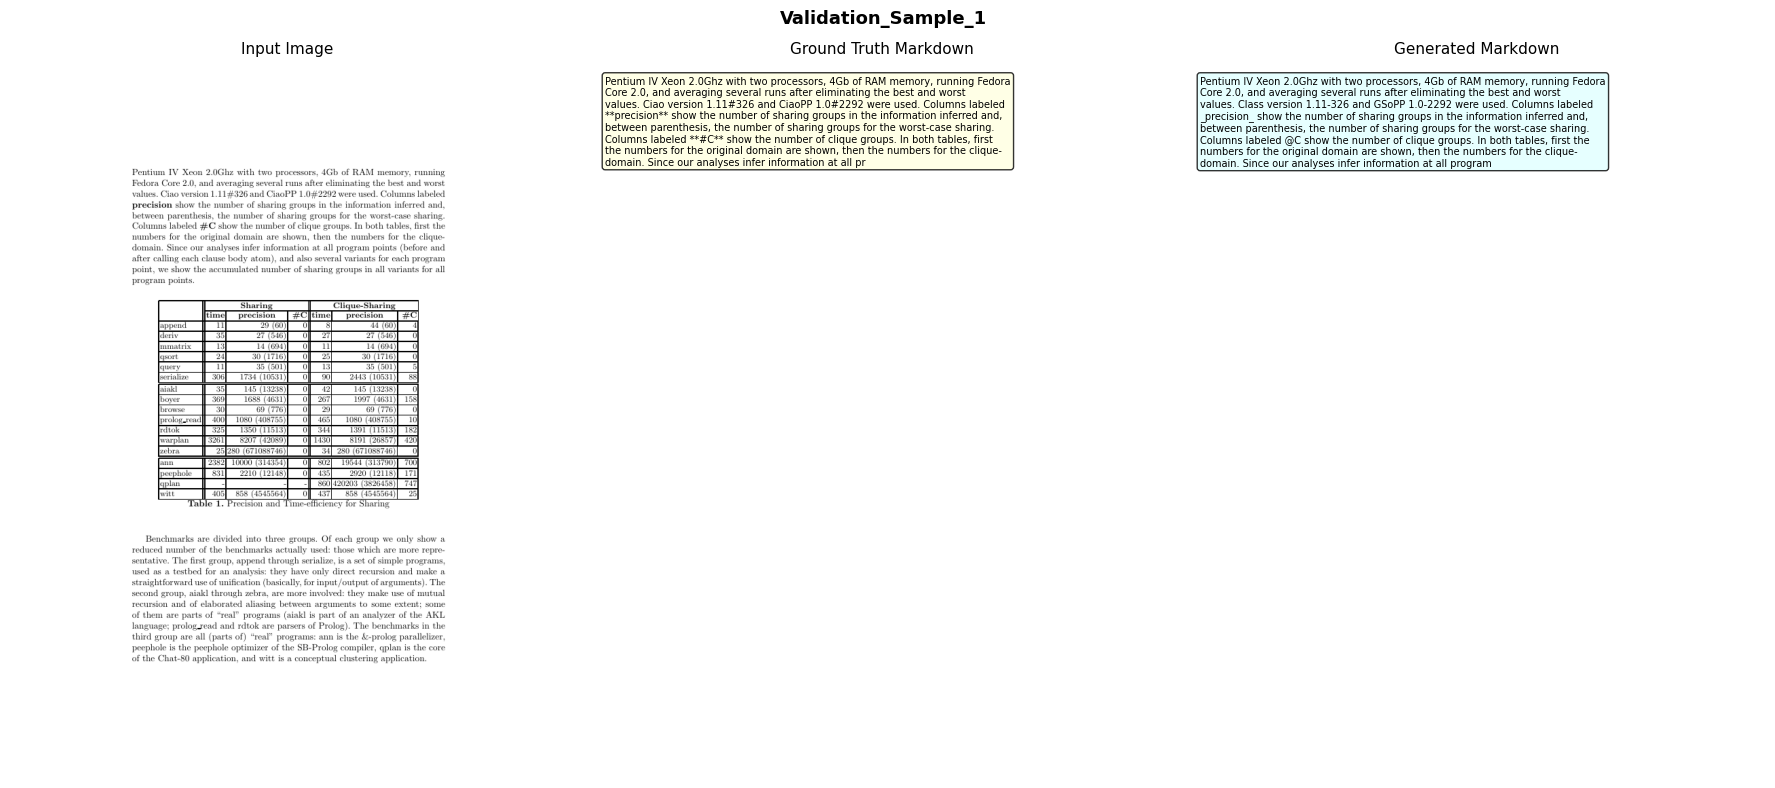

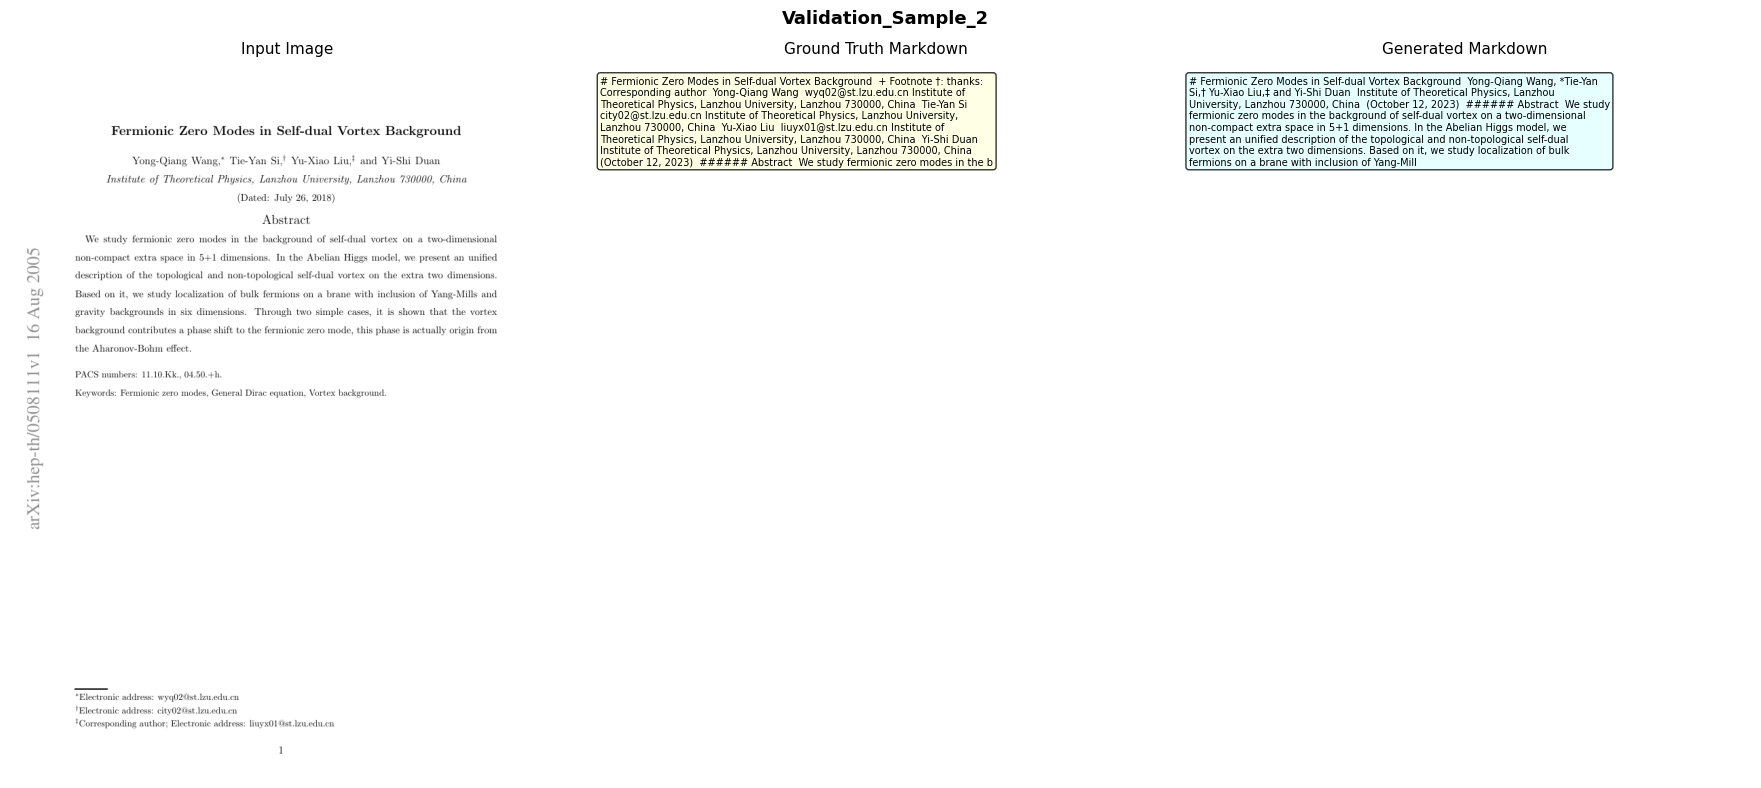

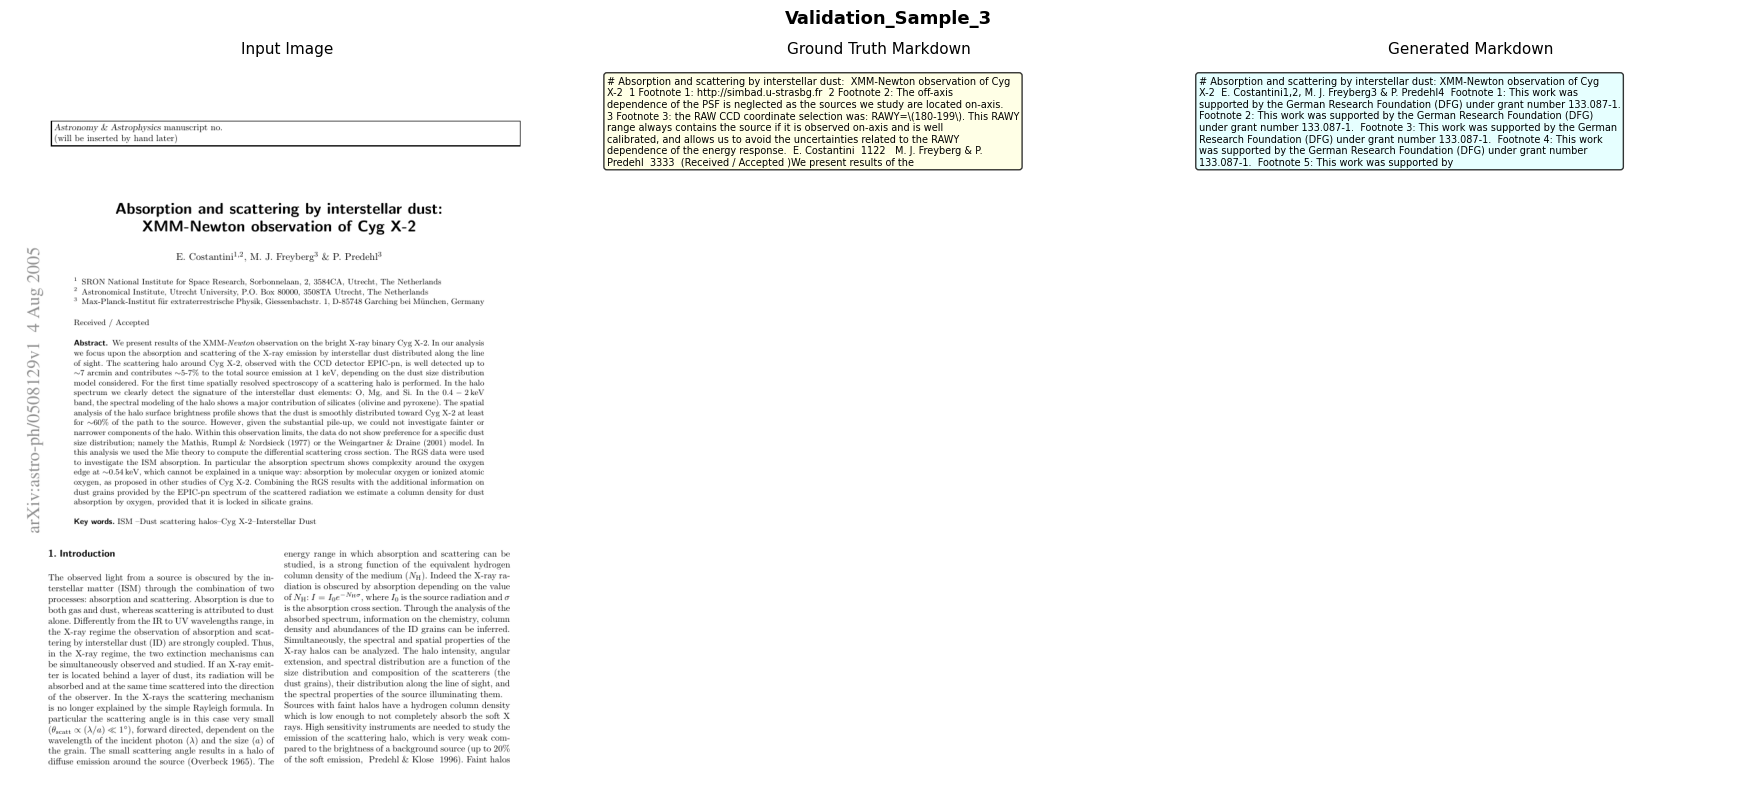

In [46]:
# Cell 24: Side-by-side visualization — image | ground truth | generated
import textwrap

def visualize_result(result, title=""):
    fig, axes = plt.subplots(1, 3, figsize=(18, 8))

    img = Image.open(result["image_path"]).convert("RGB")
    axes[0].imshow(img)
    axes[0].set_title("Input Image", fontsize=11)
    axes[0].axis("off")

    gt_text = result.get("ground_truth", "N/A (unseen image)")
    wrapped_gt = "\n".join(textwrap.wrap(gt_text[:600], width=80))
    axes[1].text(0.02, 0.98, wrapped_gt, transform=axes[1].transAxes,
                 fontsize=7, verticalalignment="top", wrap=True,
                 bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
    axes[1].set_title("Ground Truth Markdown", fontsize=11)
    axes[1].axis("off")

    gen_text = result.get("generated", "")
    wrapped_gen = "\n".join(textwrap.wrap(gen_text[:600], width=80))
    axes[2].text(0.02, 0.98, wrapped_gen, transform=axes[2].transAxes,
                 fontsize=7, verticalalignment="top", wrap=True,
                 bbox=dict(boxstyle="round", facecolor="lightcyan", alpha=0.8))
    axes[2].set_title("Generated Markdown", fontsize=11)
    axes[2].axis("off")

    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold")

    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{title.replace(' ', '_').replace('/', '_')}.png", dpi=120)
    plt.show()

for i, res in enumerate(val_results):
    visualize_result(res, title=f"Validation_Sample_{i + 1}")

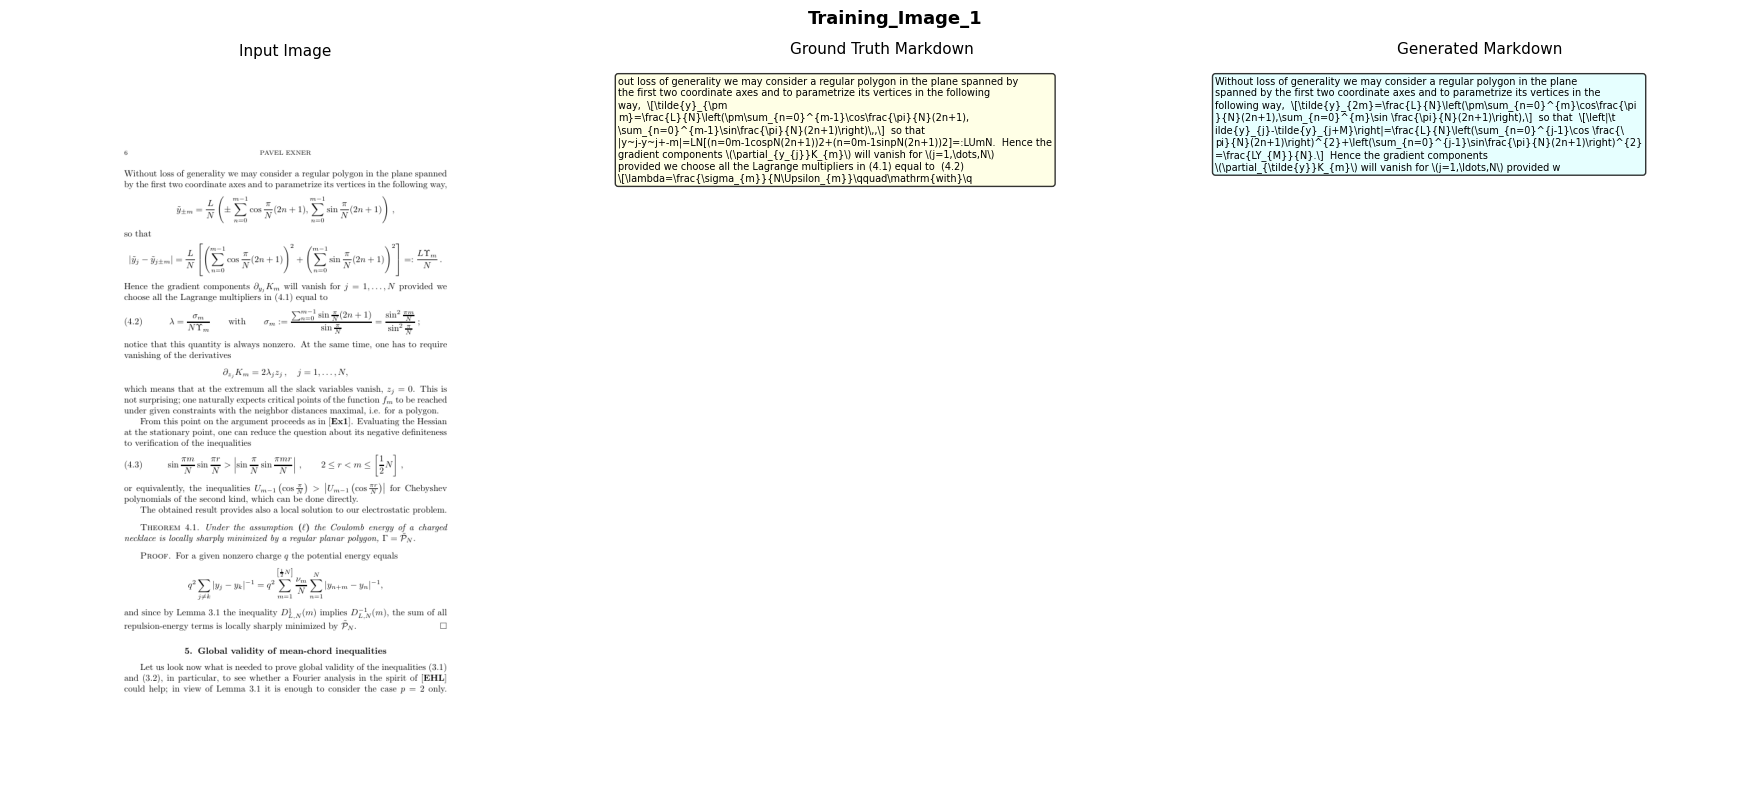

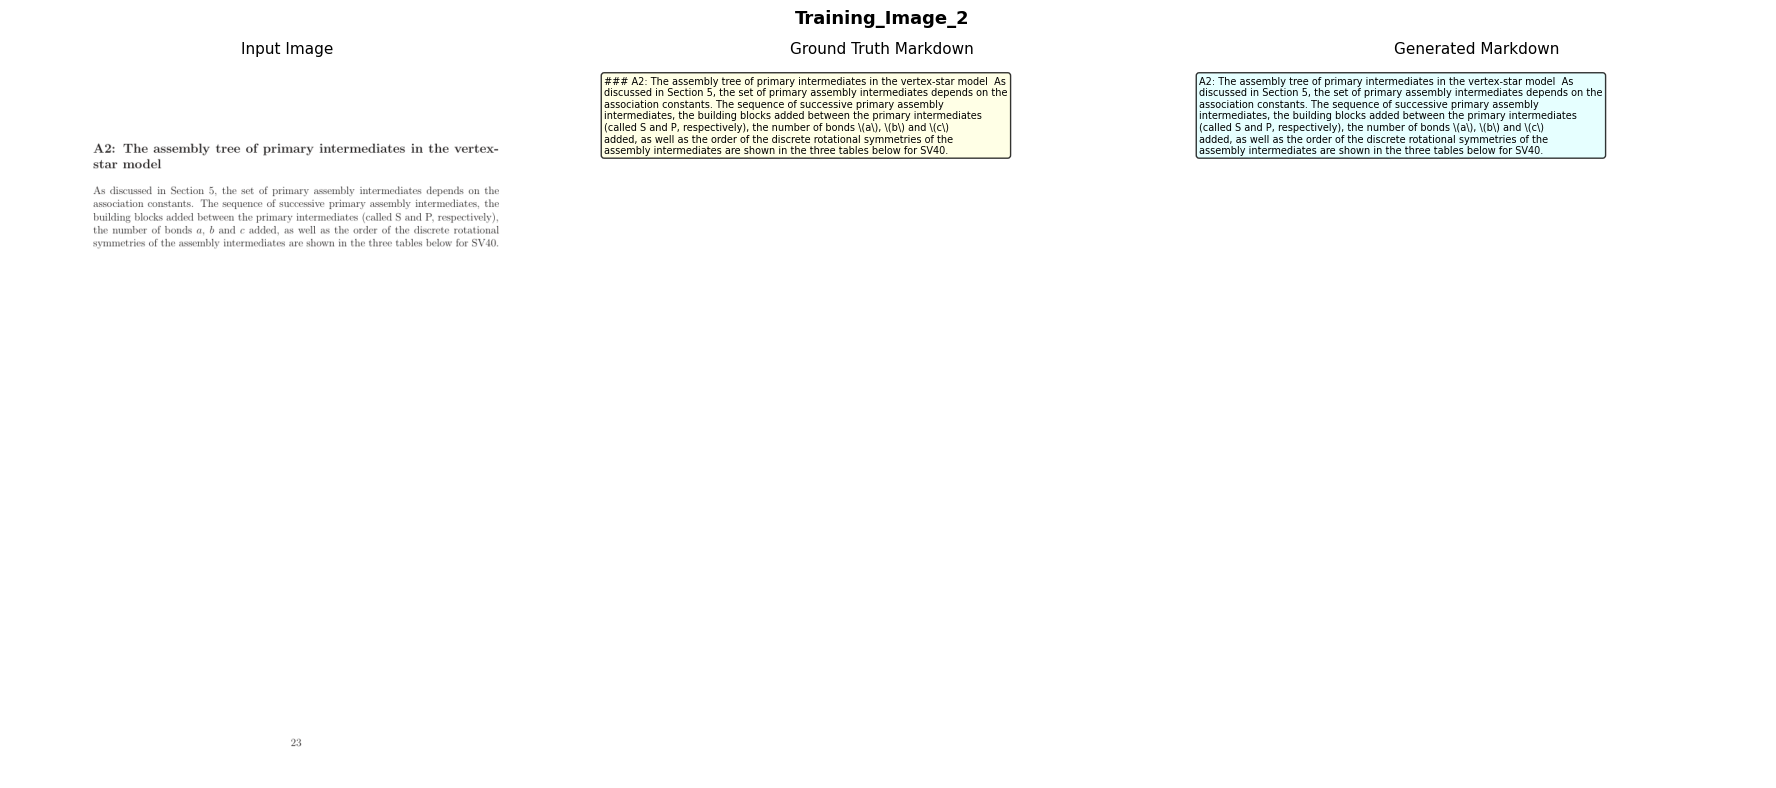

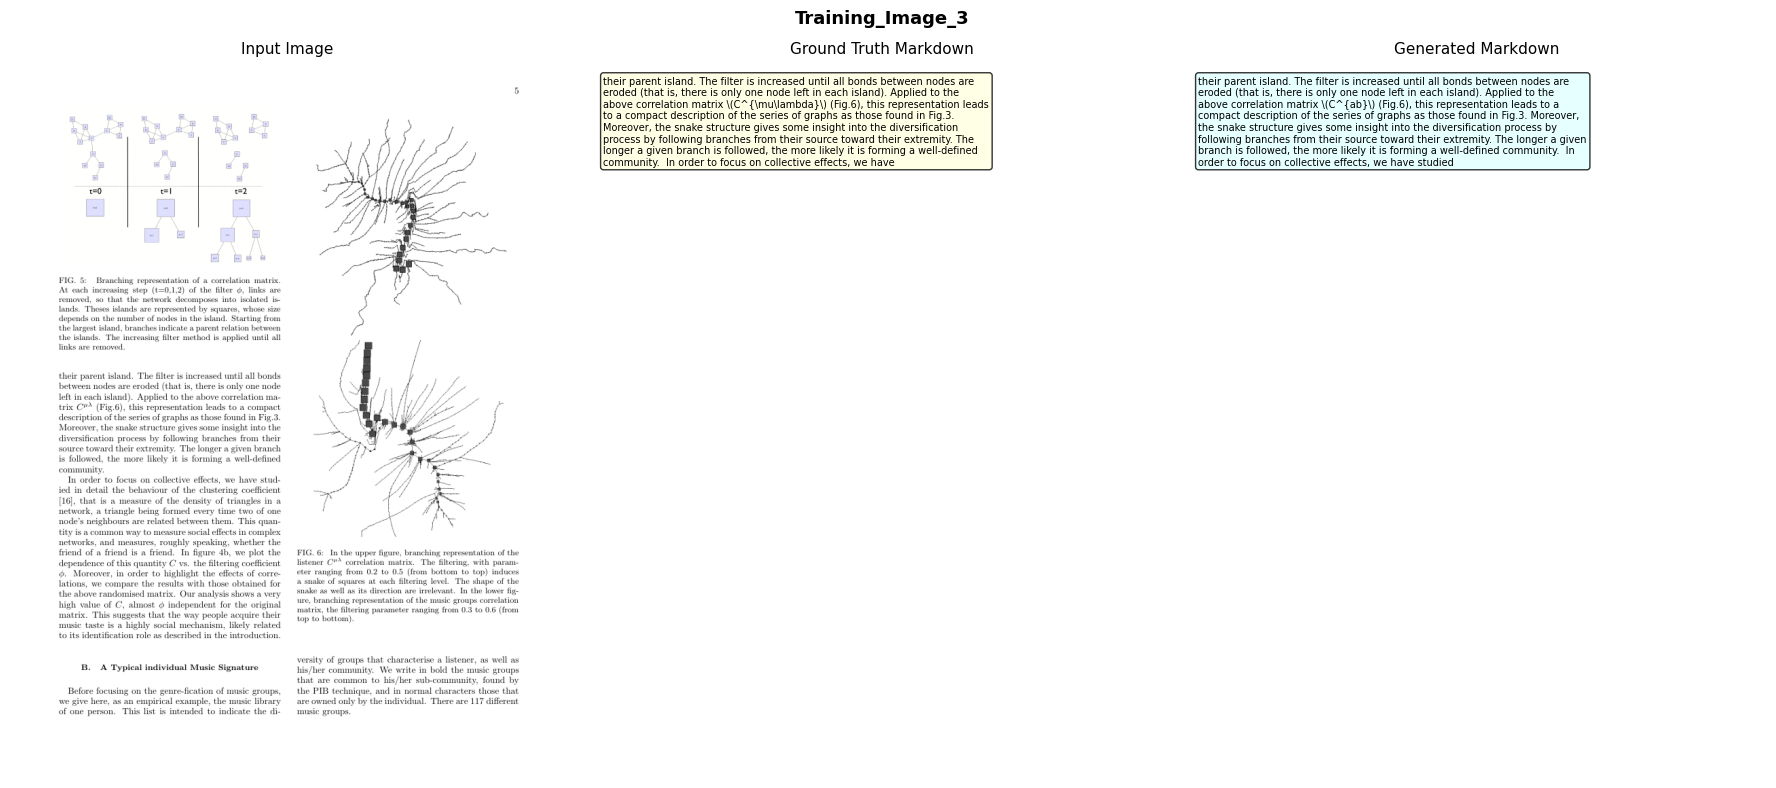

In [47]:
# Cell 25: Visualize training image outputs
for i, res in enumerate(train_test_results):
    if "ground_truth" not in res:
        res["ground_truth"] = train_test_samples[i]["target"]
    visualize_result(res, title=f"Training_Image_{i + 1}")

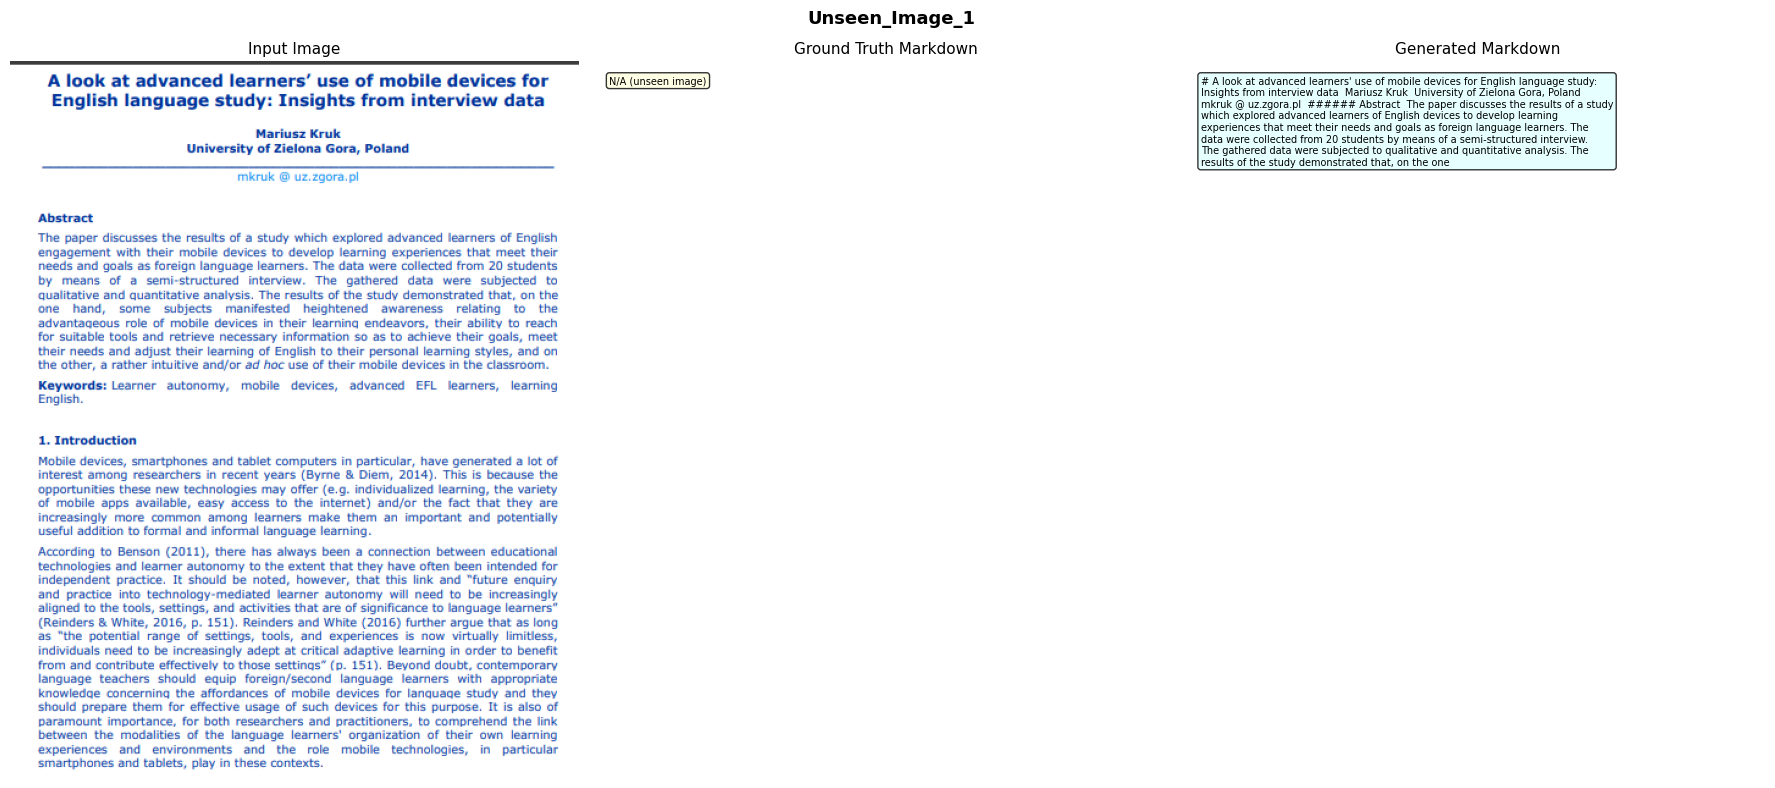

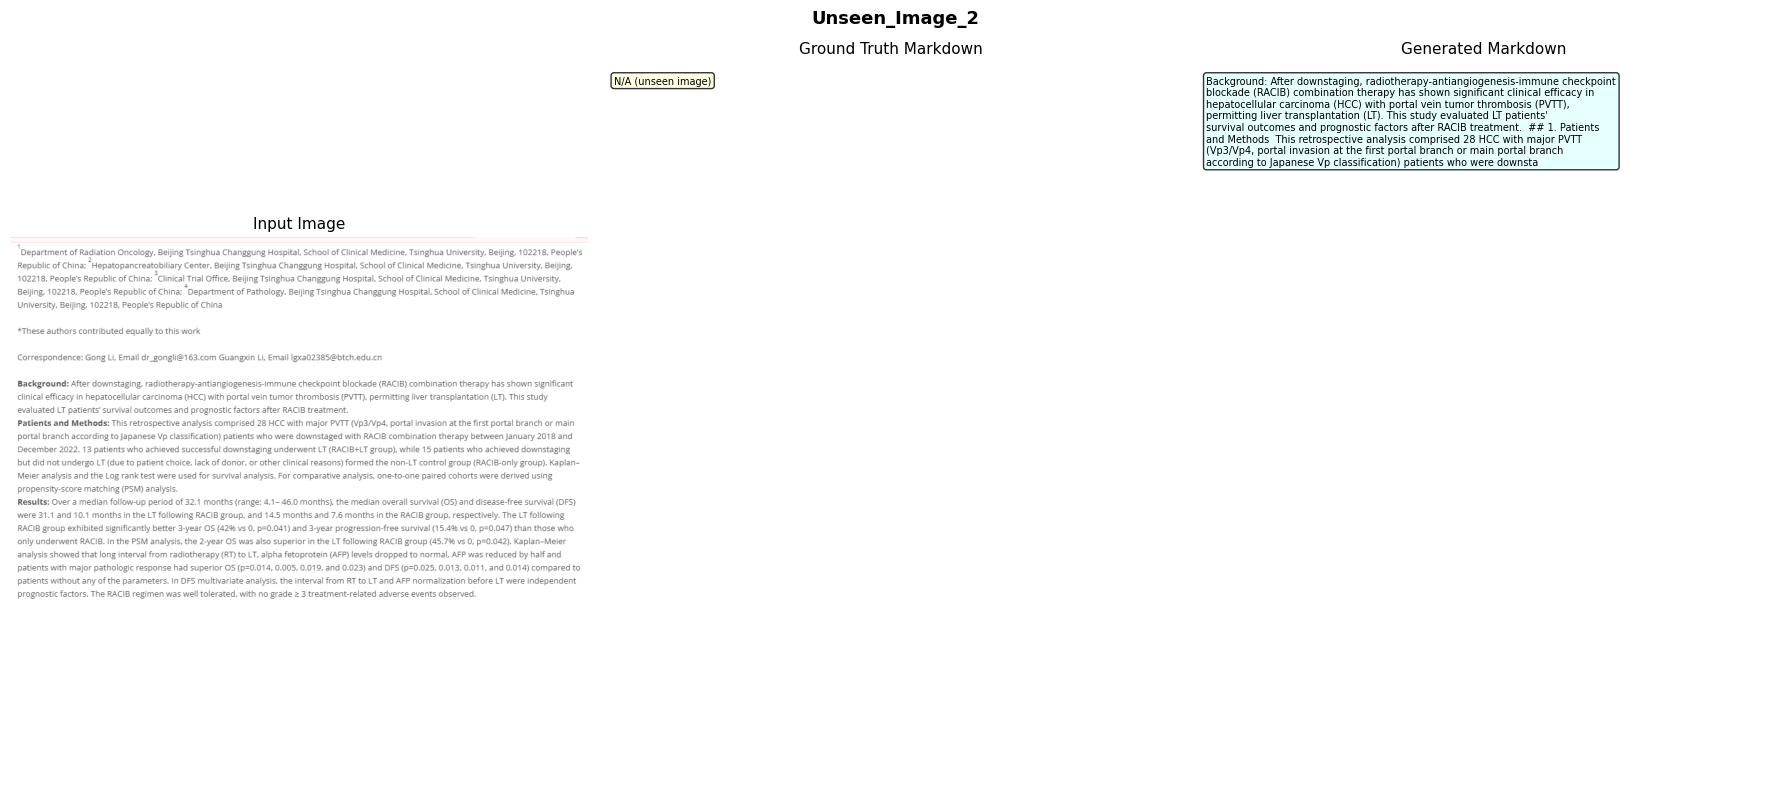

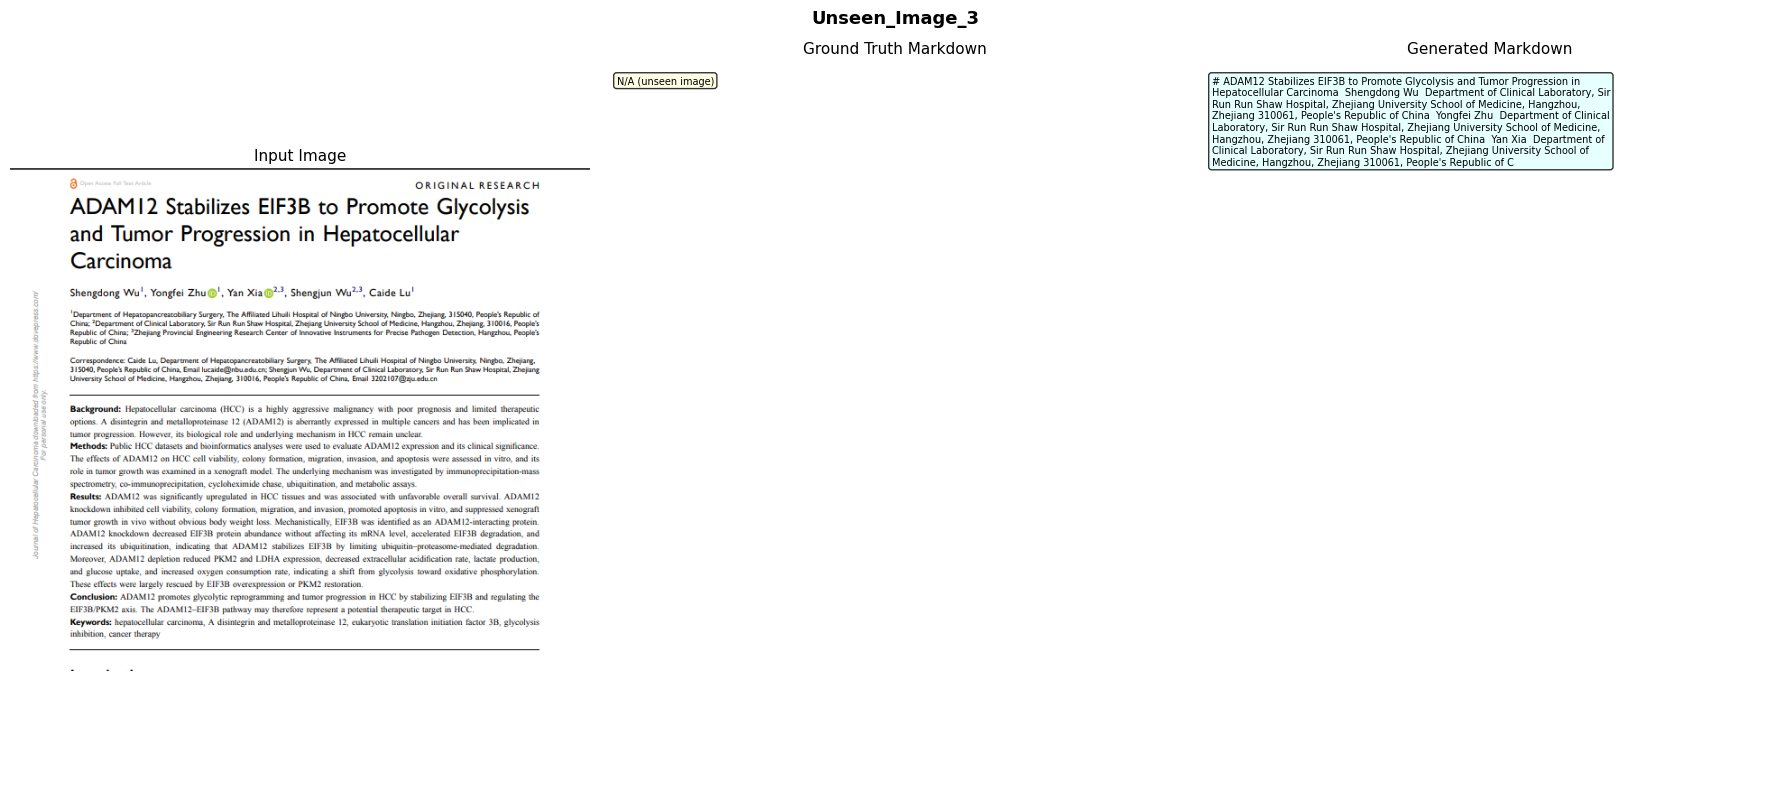

In [49]:
# Cell 26: Visualize unseen image outputs
for i, res in enumerate(unseen_results):
    visualize_result(res, title=f"Unseen_Image_{i + 1}")

## App Deployment: Gradio Interface

In [29]:
# Cell 27: Gradio app
import gradio as gr

def run_inference(uploaded_image):
    if uploaded_image is None:
        return "Please upload an image."

    tmp_path = "/kaggle/working/tmp_gradio_input.png"
    if isinstance(uploaded_image, np.ndarray):
        Image.fromarray(uploaded_image).save(tmp_path)
    else:
        uploaded_image.save(tmp_path)

    result = generate_markdown(inf_model, inf_processor, tmp_path)
    return result

demo = gr.Interface(
    fn=run_inference,
    inputs=gr.Image(type="pil", label="Upload Document Image"),
    outputs=gr.Textbox(label="Generated Markdown", lines=25),
    title="Document to Markdown — Qwen2-VL + QLoRA",
    description="Upload a document image and the fine-tuned model will generate structured Markdown output."
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://dea8c092ab9b5a3275.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Bonus: Zero-Shot vs Fine-Tuned Comparison

In [30]:
# Cell 28: Load the original base model weights (no LoRA) for zero-shot test
zeroshot_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)
zeroshot_model.eval()
zeroshot_processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
print("Zero-shot base model loaded.")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Zero-shot base model loaded.


In [42]:
# Cell 29: Compare zero-shot vs fine-tuned on one validation image
test_rec = val_data[0]

zs_output  = generate_markdown(zeroshot_model, zeroshot_processor, test_rec["image_path"])
ft_output  = generate_markdown(inf_model,      inf_processor,      test_rec["image_path"])
ground_truth = test_rec["target"]

print("GROUND TRUTH (first 400 chars):")
print(ground_truth[:900])

print("\nZERO-SHOT OUTPUT (first 400 chars):")
print(zs_output[:900])

print("\nFINE-TUNED OUTPUT (first 400 chars):")
print(ft_output[:900])

GROUND TRUTH (first 400 chars):
Pentium IV Xeon 2.0Ghz with two processors, 4Gb of RAM memory, running Fedora Core 2.0, and averaging several runs after eliminating the best and worst values. Ciao version 1.11#326 and CiaoPP 1.0#2292 were used. Columns labeled **precision** show the number of sharing groups in the information inferred and, between parenthesis, the number of sharing groups for the worst-case sharing. Columns labeled **#C** show the number of clique groups. In both tables, first the numbers for the original domain are shown, then the numbers for the clique-domain. Since our analyses infer information at all program points (before and after calling each clause body atom), and also several variants for each program point, we show the accumulated number of sharing groups in all variants for all program points.



Benchmarks are divided into three groups. Of each group we only show a reduced number of the be

ZERO-SHOT OUTPUT (first 400 chars):
Pentium IV Xeon 2.0GHz with tw

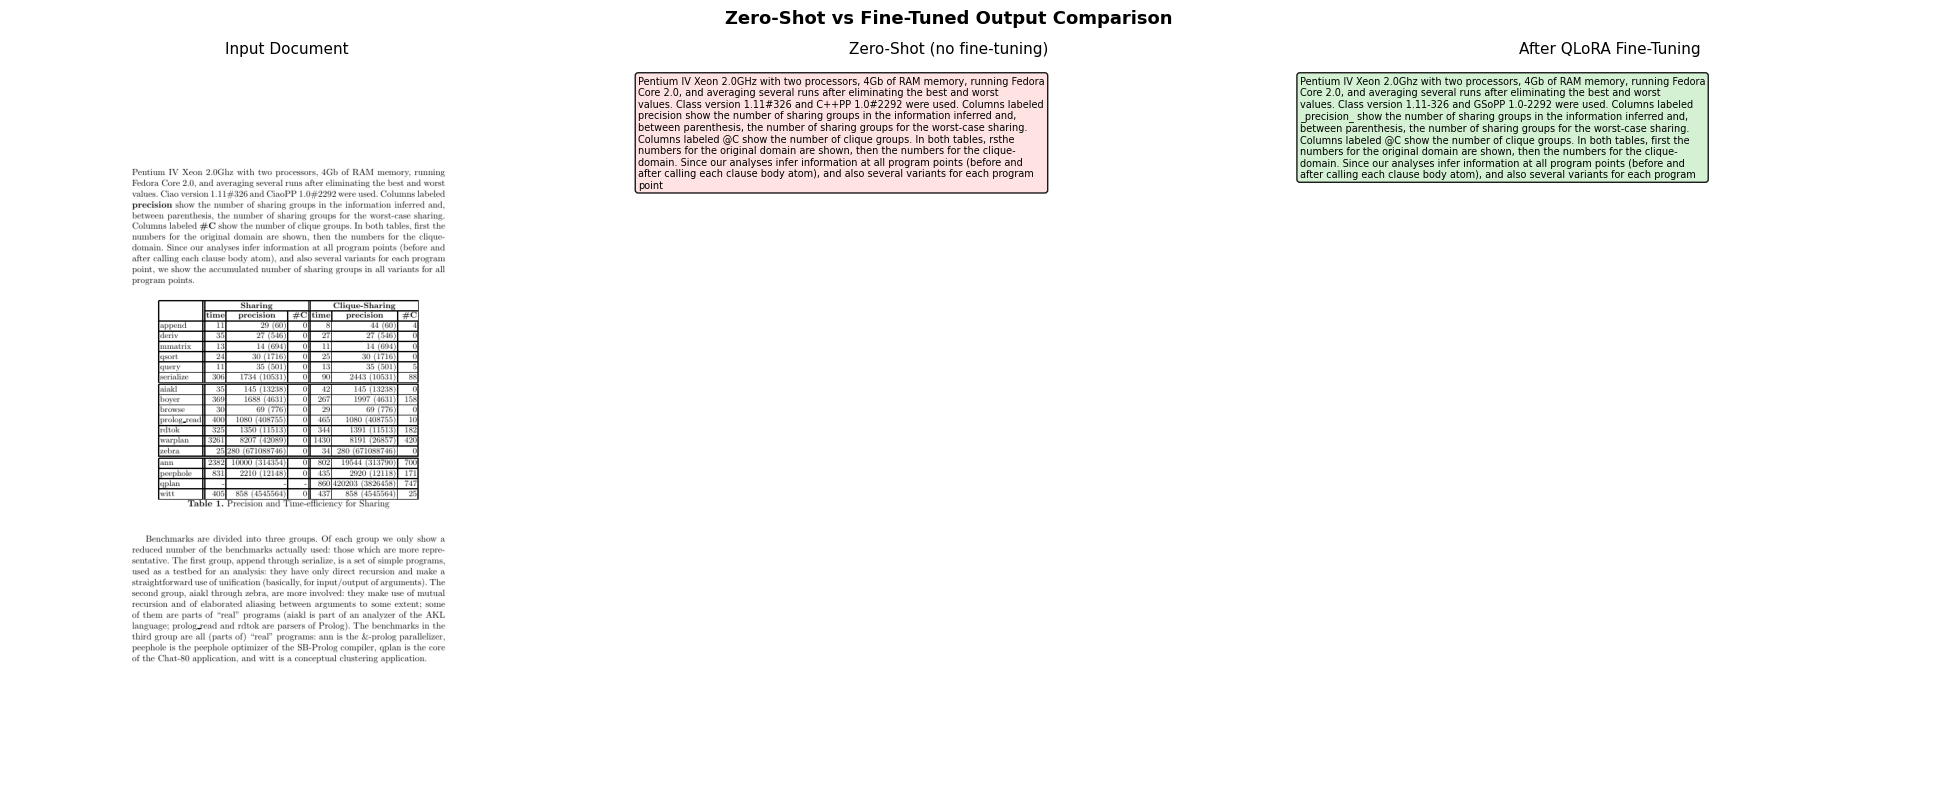

In [45]:
# Cell 30: Visual comparison — zero-shot vs fine-tuned
# Line breaks add karo for better readability
import textwrap

wrapped_zs = "\n".join(textwrap.wrap(zs_output[:700], width=80))
wrapped_ft = "\n".join(textwrap.wrap(ft_output[:700], width=80))

img = Image.open(test_rec["image_path"]).convert("RGB")

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

axes[0].imshow(img)
axes[0].set_title("Input Document", fontsize=11)
axes[0].axis("off")

# Yahan wrapped_zs use karo, zs_output nahi
axes[1].text(0.02, 0.98, wrapped_zs, transform=axes[1].transAxes,
             fontsize=7, verticalalignment="top", wrap=True,
             bbox=dict(boxstyle="round", facecolor="#ffe0e0", alpha=0.9))
axes[1].set_title("Zero-Shot (no fine-tuning)", fontsize=11)
axes[1].axis("off")

# Yahan wrapped_ft use karo, ft_output nahi
axes[2].text(0.02, 0.98, wrapped_ft, transform=axes[2].transAxes,
             fontsize=7, verticalalignment="top", wrap=True,
             bbox=dict(boxstyle="round", facecolor="#d0f0d0", alpha=0.9))
axes[2].set_title("After QLoRA Fine-Tuning", fontsize=11)
axes[2].axis("off")

fig.suptitle("Zero-Shot vs Fine-Tuned Output Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/zero_vs_finetuned.png", dpi=120)
plt.show()

In [36]:
import shutil

shutil.make_archive("/kaggle/working/best_model", "zip", "/kaggle/working/checkpoints/epoch_2")
print("Done! Download: /kaggle/working/best_model.zip")

Done! Download: /kaggle/working/best_model.zip
